In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# #drop_cols = [
# 'ONEOFF_PURCHASES',
# 'PURCHASES_INSTALLMENTS_FREQUENCY',
# 'CASH_ADVANCE_FREQUENCY'
# ]

In [3]:
cd = pd.read_excel('cd_all.xlsx')
cd.isna().sum()

BALANCE                         0
BALANCE_FREQUENCY               0
PURCHASES                       0
INSTALLMENTS_PURCHASES          0
CASH_ADVANCE                    0
PURCHASES_FREQUENCY             0
ONEOFF_PURCHASES_FREQUENCY      0
CASH_ADVANCE_TRX                0
PURCHASES_TRX                   0
CREDIT_LIMIT                    1
PAYMENTS                        0
MINIMUM_PAYMENTS              313
PRC_FULL_PAYMENT                0
TENURE                          0
dtype: int64

In [4]:
#заполнение столбца MINIMUM_PAYMENTS нулем, так как это означает отсутствие обязательств у клиента, сегментируя его как дисциплинированного
cd['MINIMUM_PAYMENTS'] = cd['MINIMUM_PAYMENTS'].fillna(0)
cd['CREDIT_LIMIT'] = cd['CREDIT_LIMIT'].fillna(cd['CREDIT_LIMIT'].median())
cd.dropna(inplace=True)
print(cd.isna().sum())

BALANCE                       0
BALANCE_FREQUENCY             0
PURCHASES                     0
INSTALLMENTS_PURCHASES        0
CASH_ADVANCE                  0
PURCHASES_FREQUENCY           0
ONEOFF_PURCHASES_FREQUENCY    0
CASH_ADVANCE_TRX              0
PURCHASES_TRX                 0
CREDIT_LIMIT                  0
PAYMENTS                      0
MINIMUM_PAYMENTS              0
PRC_FULL_PAYMENT              0
TENURE                        0
dtype: int64


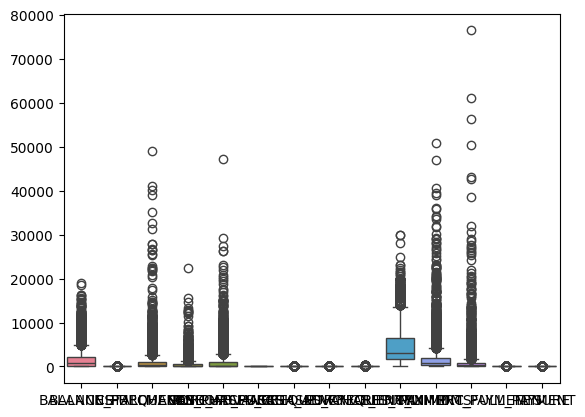

In [5]:
#проверим наличие выбросов
sns.boxplot(data = cd)
plt.show()

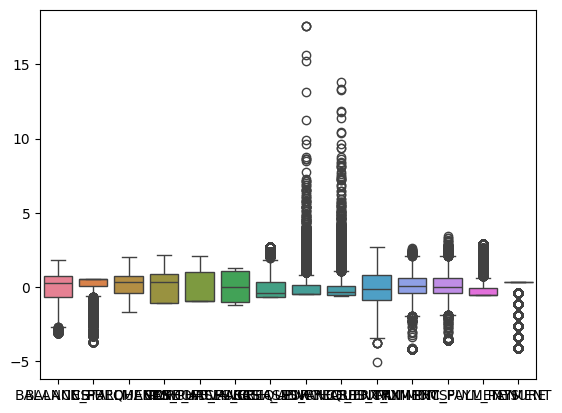

In [6]:
#Масштабирование признаков
from sklearn.preprocessing import StandardScaler
#Логарифмирование денежных показателей
cd[['BALANCE', 'PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS']]= np.log1p(cd[['BALANCE', 'PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS']])
scaler = StandardScaler().set_output(transform="pandas")
# Обучаем scaler и трансформируем ВСЕ признаки (включая частотные и tenure)
scaler = scaler.fit(cd)
cd_scaled = scaler.transform(cd)
sns.boxplot(cd_scaled)
plt.show()

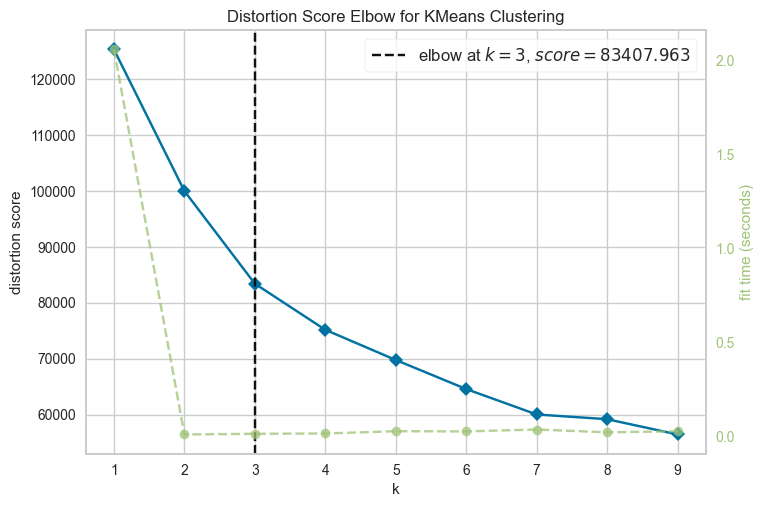

In [7]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

model_KMeans = KMeans(random_state=42)
visualizer = KElbowVisualizer(model_KMeans, k=(1,10))

visualizer.fit(cd_scaled)
visualizer.show()
plt.show()

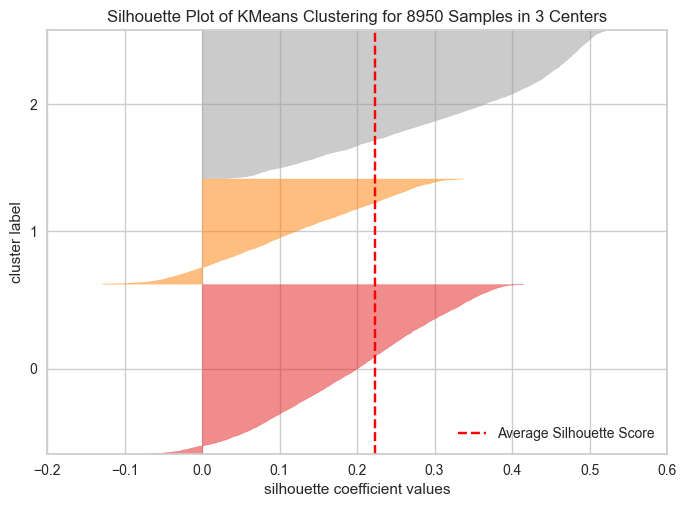

In [10]:
model_KMeans_3 = KMeans(random_state=42, n_clusters=3)

from yellowbrick.cluster import SilhouetteVisualizer

silhouette_3 = SilhouetteVisualizer(model_KMeans_3)

silhouette_3.fit(cd_scaled)        # Fit the data to the visualizer
silhouette_3.show()        # Finalize and render the figure
plt.show()

In [11]:
#Проведем кластеризацию с выделением трех кластеров

cd_KMeans_3 = model_KMeans_3.fit(cd_scaled)
print(cd_KMeans_3.labels_)
print(cd_KMeans_3.inertia_)

[1 2 0 ... 1 1 1]
83408.03784770178


In [17]:
#Для удобства добавим метки кластеров к DataFrame с данными
labels_3 = pd.Series(cd_KMeans_3.labels_, index=cd_scaled.index, name='Clusters')

cd_3 = pd.concat([cd_scaled, labels_3], axis=1)

display(cd_3.groupby('Clusters').mean().round(1))

,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Clusters,,,,,,,,,,,,,,
0,0.3,0.4,0.8,0.7,-0.3,0.9,0.7,-0.1,0.6,0.3,0.4,0.3,0.1,0.2
1,-1.3,-1.1,0.1,0.1,-0.7,0.0,-0.4,-0.4,-0.3,-0.4,-0.8,-1.1,0.5,-0.3
2,0.6,0.3,-1.0,-0.9,0.8,-1.0,-0.5,0.5,-0.5,-0.1,0.1,0.4,-0.4,-0.1


Иерархическая кластеризация

In [13]:
import scipy.cluster.hierarchy as shc
#Сначала необходимо вычислить попарные расстояния между наблюдениями в n-мерном пространстве (матрицу расстояний). Это можно сделать с помощью функции [`pdist`]
from scipy.spatial.distance import pdist

distance_matrix = pdist(cd_scaled)

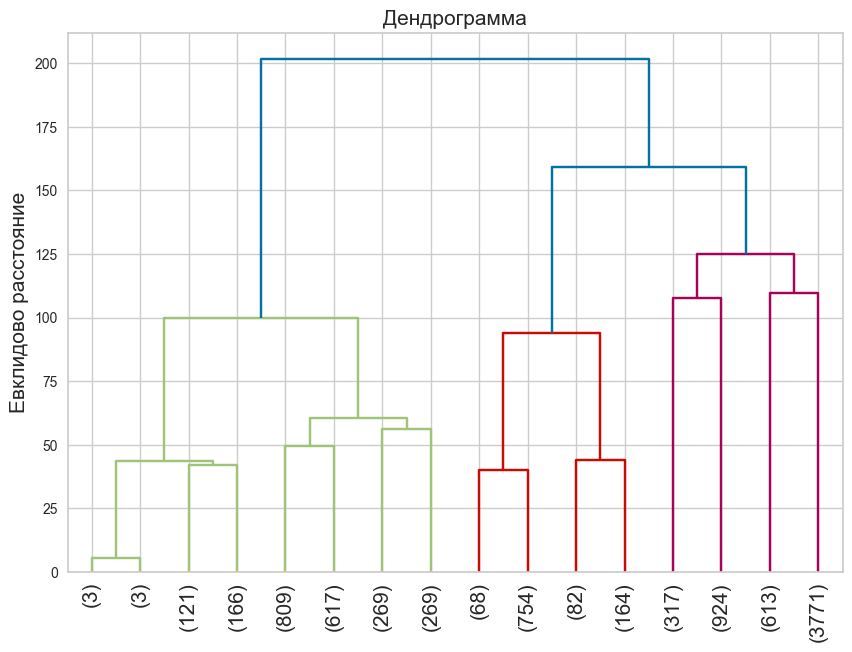

In [14]:
#Функция [linkage()] выполняет иерархическую (агломеративную) кластеризацию
Z = shc.linkage(distance_matrix, method='ward')

plt.figure(figsize=(10, 7))
dendrogram = shc.dendrogram(Z, labels=cd_scaled.index, leaf_rotation=90, leaf_font_size=15, truncate_mode='level', p=3)
plt.title("Дендрограмма", fontsize=15)
plt.ylabel("Евклидово расстояние", fontsize=15)
plt.show()

In [16]:
#Выделим 3 кластера и определим объекты, которые были включены в каждый из них
cd_shc_3_labels = shc.fcluster(Z, 3, criterion='maxclust')

#Преобразуем объект типа numpy.ndarray в Series
labels_shc_3 = pd.Series(cd_shc_3_labels, index=cd_scaled.index, name='Clusters')

#Функция `pandas.concat()` объединяет объекты `pandas` вдоль определенной оси
cd_shc_3 = pd.concat([cd_scaled, labels_shc_3], axis=1)

display(cd_shc_3.groupby('Clusters').mean().round(1))

,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Clusters,,,,,,,,,,,,,,
1,0.5,0.1,-1.4,-1.0,1.0,-1.1,-0.5,0.7,-0.5,-0.1,0.2,0.4,-0.4,-0.0
2,-1.5,-1.8,0.1,-0.1,-0.7,-0.3,-0.4,-0.4,-0.3,-0.1,-1.2,-1.6,-0.2,0.1
3,0.1,0.3,0.5,0.4,-0.3,0.5,0.3,-0.2,0.3,0.0,0.2,0.1,0.2,-0.0


In [18]:
# 1. Загружаем и чистим данные заново, чтобы вернуть реальный масштаб (доллары)
cd_real = pd.read_excel('cd_all.xlsx')
cd_real['MINIMUM_PAYMENTS'] = cd_real['MINIMUM_PAYMENTS'].fillna(0)
cd_real['CREDIT_LIMIT'] = cd_real['CREDIT_LIMIT'].fillna(cd_real['CREDIT_LIMIT'].median())
cd_real.dropna(inplace=True)

# 2. Добавляем в этот чистый датасет колонку с метками кластеров, которые нашла модель K-Means
cd_real['Cluster'] = model_KMeans_3.labels_

# 3. Группируем по кластерам, считаем среднее арифметическое и округляем до 2 знаков
interpretation_table = cd_real.groupby('Cluster').mean().round(2)

# Отображаем таблицу
display(interpretation_table)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,
0,1815.46,0.98,2108.09,863.25,665.38,0.84,0.40,2.23,30.85,5460.18,2422.86,1075.18,0.18,11.81
1,117.33,0.62,418.48,238.45,102.04,0.49,0.08,0.35,7.25,3285.66,627.55,108.44,0.29,11.18
2,2309.20,0.94,151.74,15.00,1964.75,0.09,0.06,6.48,1.50,4247.75,1730.24,1074.87,0.03,11.43


Кластер 0
Профиль в цифрах: Высокий средний баланс (~1815$), абсолютные лидеры по объёму покупок (~2108$), высокая частота покупок (0.84), самый высокий кредитный лимит (~5460$). Часто покупают в рассрочку (~863$). Наличные почти не снимают.

Портрет: Это самые вовлечённые и лояльные клиенты банка. Они активно используют карту в повседневной жизни, покупают как дорогие товары в рассрочку, так и совершают регулярные транзакции. Приносят банку доход за счёт интерчейнджа (комиссии, которую платят магазины банку за каждую транзакцию по карте).

Стратегия банка: Удерживать и стимулировать. Предлагать программы кэшбэка на популярные категории, кобрендинговые карты, повышать кредитный лимит, предлагать премиальное обслуживание.

Кластер 1
Профиль в цифрах: Самый низкий баланс (~117$), минимальные редкие покупки (~418$), низкий кредитный лимит (~3285$). Почти не снимают наличные. При этом у них самый высокий показатель полной оплаты долга (PRC_FULL_PAYMENT = 0.29).

Портрет: «Дисциплинированные невидимки». Клиенты, которые либо оформили карту недавно, либо держат её «на всякий случай». Они практически не уходят в долг перед банком, гасят всё вовремя в грейс-период, не платят проценты по кредиту, но и транзакционную активность проявляют слабую.

Стратегия банка: Разогревать активность. Присылать таргетные push-уведомления с акциями (например: «Совершите покупку от 20$ и получите бонус»), предлагать приветственные баллы, выявлять их реальные потребности.

Кластер 2
Профиль в цифрах: Самый высокий баланс/задолженность (~2309$). Покупки практически на нуле (~151$), но абсолютные лидеры по снятию наличных (~1964$) и транзакциям cash-advance. Процент полной оплаты долга критически низкий (всего 0.03).

Портрет: Люди, использующие кредитную карту не для покупок в магазинах, а как классический быстрый микрозайм наличными. Они снимают кэш в банкоматах, выходят за рамки льготного периода, платят банку огромные комиссии за снятие и баснословные проценты по кредиту, так как гасят задолженность только минимальными платежами. Это главный источник процентного дохода банка, но одновременно и зона повышенного кредитного риска.

Стратегия банка: Мониторинг рисков и рефинансирование. Внимательно следить за их просрочками, не повышать им лимит бесконтрольно. Выгодно предложить им перейти на классический потребительский кредит или кредит наличными с фиксированным графиком выплат, чтобы снизить риск дефолта.



Несмотря на то, что средний баланс (BALANCE) у Кластера 0 и Кластера 2 высокий, их кредитное поведение противоположно. У Кластера 2 баланс сформирован за счет невозвратного снятия наличных (высокий CASH_ADVANCE и нулевой PRC_FULL_PAYMENT), что говорит о классической кредитной задолженности. А у Кластера 0 баланс высокий из-за огромного текущего оборота покупок и выплат (PURCHASES и PAYMENTS превышают сам баланс), что характеризует их как активных и состоятельных пользователей карт, а не проблемных заемщиков

MINIMUM_PAYMENTS — это нормативное требование банка, которое зависит исключительно от размера баланса. Поскольку балансы у Кластера 0 и Кластера 2 одинаково высоки, банк выставляет им схожие минимальные требования.

Однако их реальное кредитное поведение противоположно, что видно при сравнении признака MINIMUM_PAYMENTS с признаком PAYMENTS (фактические выплаты). Клиенты Кластера 2 платят строго по нижней планке, выполняя лишь обязательное требование банка (их PAYMENTS близок к MINIMUM_PAYMENTS). В то время как клиенты Кластера 0 совершают сверхвыплаты, значительно превышающие установленный банком минимум, чтобы покрыть свой высокий транзакционный оборот покупок».